##Student Id : 2408564
#Name: Alina Shrestha
#Language Task - Part III
### News Category Classification using RNN, LSTM & BiLSTM + GloVe




**Task:** Predict the news category from a headline using three deep learning models:
- **Model 1:** Simple RNN with trainable Embedding
- **Model 2:** LSTM with trainable Embedding
- **Model 3:** BiLSTM with Pre-trained GloVe Twitter 100 Embeddings

**Dataset:** `news_category.csv` — columns: `headline`, `category`




##  1 — Install Dependencies


In [ ]:
# Run once, then restart runtime
!pip install gensim -q
!pip install wordcloud -q
!pip install contractions -q
!pip install gradio -q
print("All packages installed. Restart runtime now if this is your first run.")

✅ All packages installed. Restart runtime now if this is your first run.



##  Section 2 — Import Libraries

In [ ]:
import os
import re
import time
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter, defaultdict
from wordcloud import WordCloud
import contractions

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Bidirectional,
    Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version :", tf.__version__)
print("GPU Available      :", tf.config.list_physical_devices('GPU'))
print(" All libraries imported successfully.")

TensorFlow version : 2.20.0
GPU Available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All libraries imported successfully.



##   3 — Upload & Load Dataset


In [ ]:
from google.colab import files
import zipfile
import io

print("upload your zip or csv file...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"\n Uploaded: {filename}")

# Handle ZIP or CSV automatically
if filename.endswith('.zip'):
    with zipfile.ZipFile(filename, 'r') as z:
        # Find the CSV inside
        csv_files = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"Found CSV inside ZIP: {csv_files[0]}")
        with z.open(csv_files[0]) as f:
            df = pd.read_csv(f)
else:
    df = pd.read_csv(filename)

print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

📁 Please upload your zip or csv file...


Saving 6. News Category Dataset-20260509T191627Z-3-001.zip to 6. News Category Dataset-20260509T191627Z-3-001 (1).zip

✅ Uploaded: 6. News Category Dataset-20260509T191627Z-3-001 (1).zip
Found CSV inside ZIP: 6. News Category Dataset/news_category.csv

Shape: (11025, 2)
Columns: ['headline', 'category']

First 5 rows:


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


In [ ]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

df.dropna(subset=['headline', 'category'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nTotal samples       : {len(df)}")
print(f"Unique categories   : {df['category'].nunique()}")
print("\nCategory Distribution:")
print(df['category'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11025 entries, 0 to 11024
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  11025 non-null  object
 1   category  11025 non-null  object
dtypes: object(2)
memory usage: 172.4+ KB
None

Missing Values:
headline    0
category    0
dtype: int64

Total samples       : 11025
Unique categories   : 5

Category Distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64



##  4 — Data Understanding & Visualization

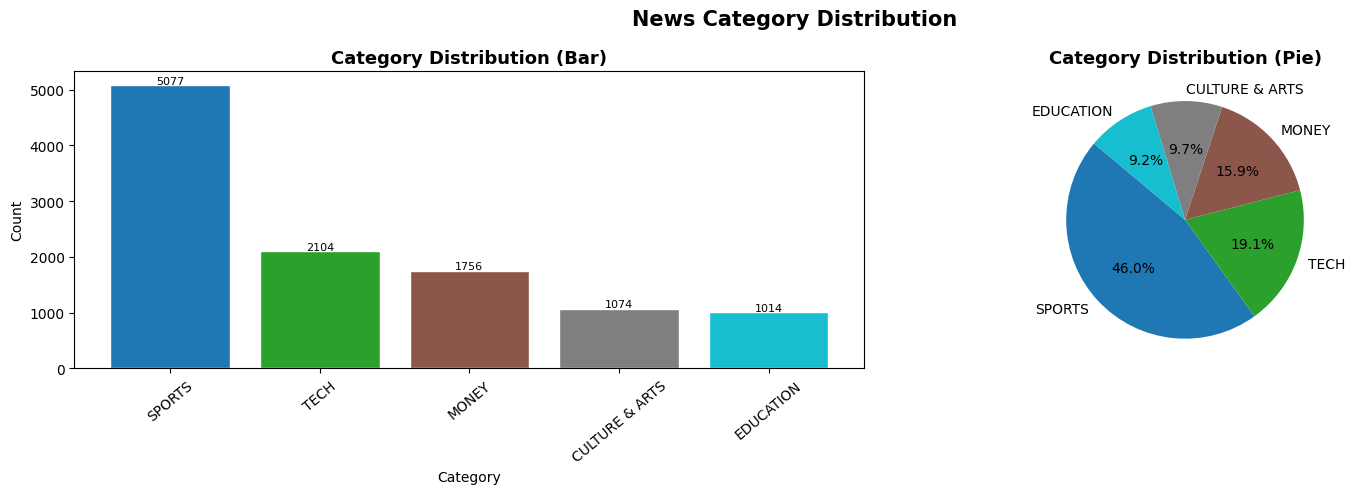

In [ ]:
# ── 4.1 Class Distribution ──────────────────────────────────────
category_counts = df['category'].value_counts()
colors = cm.tab10(np.linspace(0, 1, len(category_counts)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(category_counts.index, category_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Category Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40)
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=8)

axes[1].pie(category_counts.values, labels=category_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Category Distribution (Pie)', fontsize=13, fontweight='bold')

plt.suptitle('News Category Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##  4.2 Headline Length Distribution


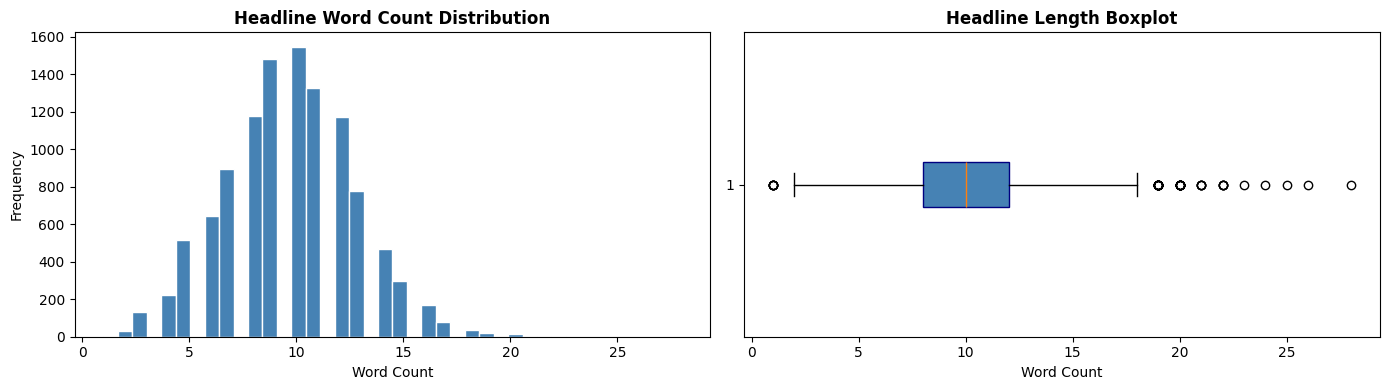

Mean headline length   : 9.8 words
Median headline length : 10.0 words
Max headline length    : 28 words
95th percentile length : 15 words


In [ ]:
df['headline_length'] = df['headline'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['headline_length'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Headline Word Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['headline_length'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Headline Length Boxplot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

print(f"Mean headline length   : {df['headline_length'].mean():.1f} words")
print(f"Median headline length : {df['headline_length'].median():.1f} words")
print(f"Max headline length    : {df['headline_length'].max()} words")
print(f"95th percentile length : {int(np.percentile(df['headline_length'], 95))} words")


##  5 — Text Preprocessing

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Expand contractions  (don't → do not)
    3. Remove URLs
    4. Remove mentions and hashtags
    5. Remove numbers and special characters
    6. Remove stopwords
    7. Lemmatize
    """
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
               if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

print("Cleaning text... (may take 1-2 minutes)")
df['clean_headline'] = df['headline'].apply(clean_text)

print("\nBefore vs After Cleaning (5 examples):")
for i in range(5):
    print(f"  ORIGINAL : {df['headline'][i]}")
    print(f"  CLEANED  : {df['clean_headline'][i]}")
    print()

Cleaning text... (may take 1-2 minutes)

Before vs After Cleaning (5 examples):
  ORIGINAL : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
  CLEANED  : new documentary capture complexity child immigrant

  ORIGINAL : Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
  CLEANED  : twitch ban gambling site streamer scam folk

  ORIGINAL : 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
  CLEANED  : reboot clever navelgazey look inside tv reboots

  ORIGINAL : Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89
  CLEANED  : maury will basestealing shortstop dodger dy

  ORIGINAL : Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
  CLEANED  : la vega ace win first wnba title chelsea gray named mvp



## 5.1 Word Cloud — All Headlines


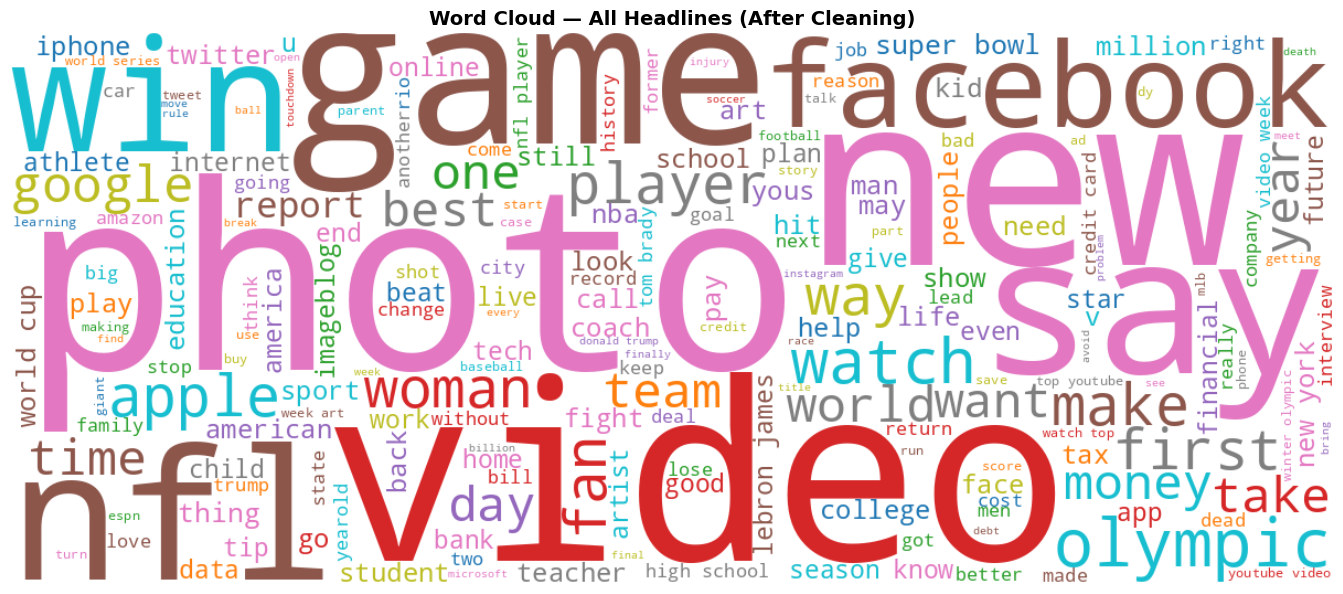

In [ ]:
all_text = ' '.join(df['clean_headline'].tolist())
wc = WordCloud(width=1200, height=500, background_color='white',
               colormap='tab10', max_words=200).generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Headlines (After Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  5.2 Top 20 Most Frequent Words


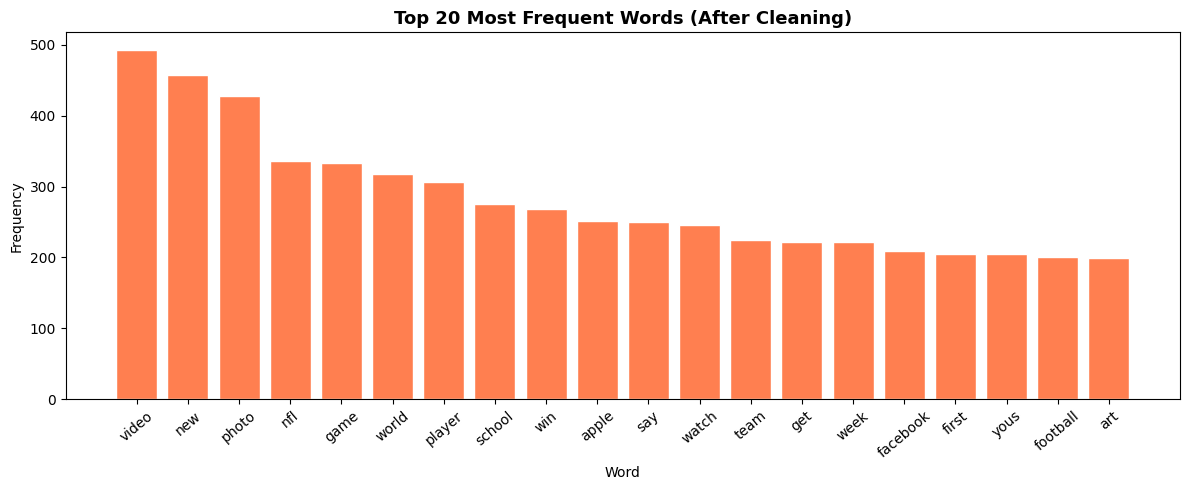

In [ ]:
all_words = ' '.join(df['clean_headline']).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(words, freqs, color='coral', edgecolor='white')
plt.title('Top 20 Most Frequent Words (After Cleaning)', fontsize=13, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

## 5.3 Per-Category Word Clouds


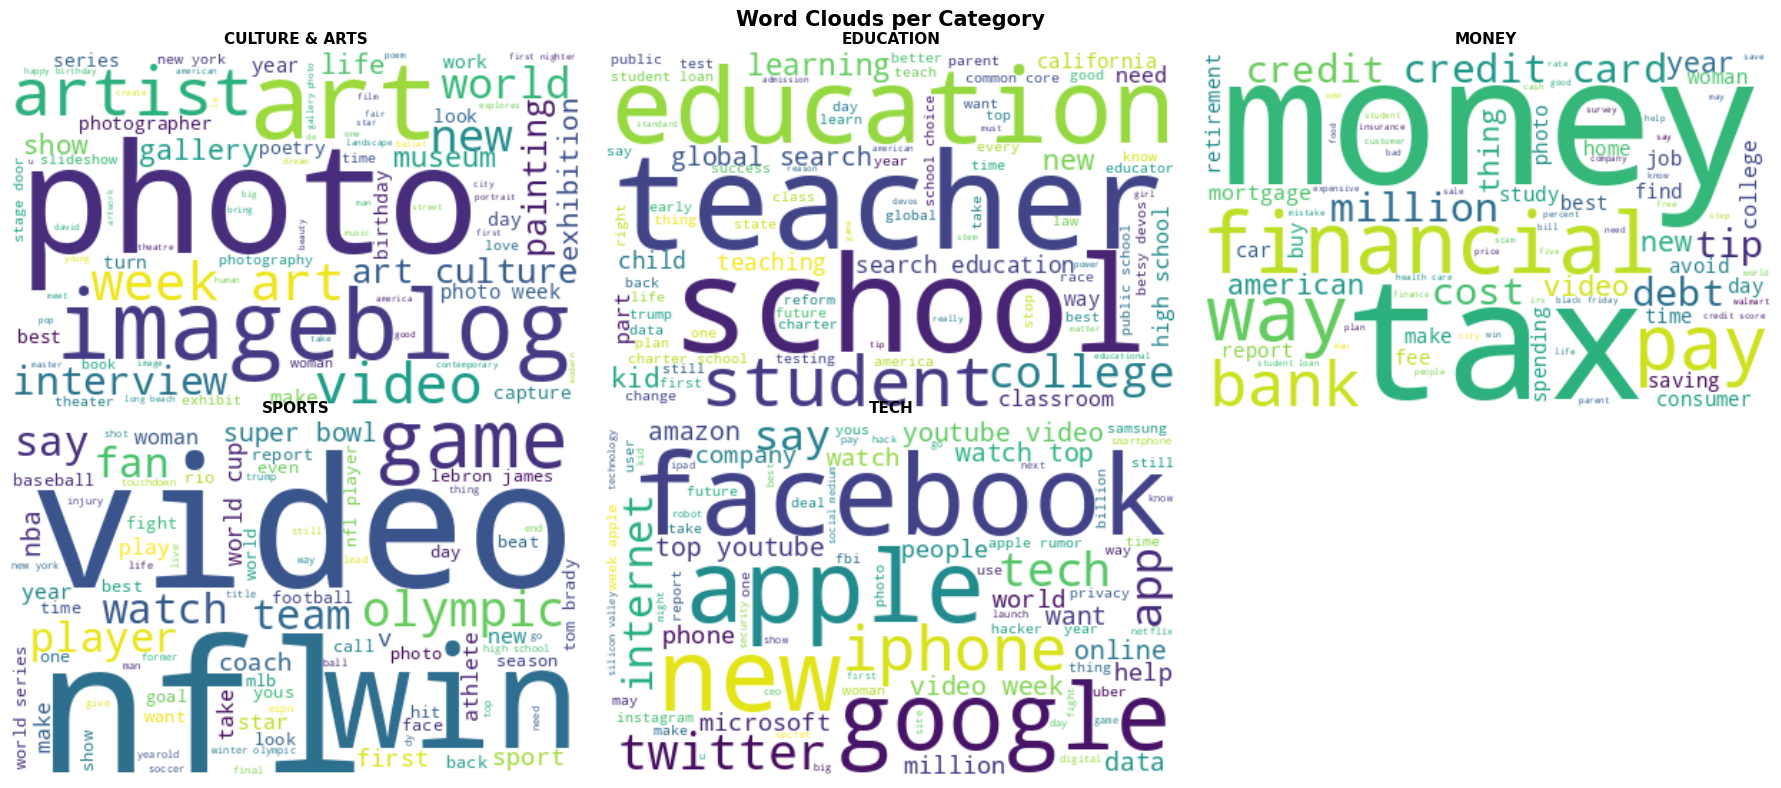

In [ ]:
categories = df['category'].unique()
n_cats = len(categories)
cols = 3
rows = (n_cats + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, cat in enumerate(sorted(categories)):
    cat_text = ' '.join(df[df['category'] == cat]['clean_headline'].tolist())
    if cat_text.strip():
        wc_cat = WordCloud(width=400, height=250, background_color='white',
                           colormap='viridis', max_words=80).generate(cat_text)
        axes[i].imshow(wc_cat, interpolation='bilinear')
    axes[i].set_title(cat, fontsize=11, fontweight='bold')
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Word Clouds per Category', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


##  6 — Tokenization, Label Encoding & Padding

In [ ]:
# ── 6.1 Label Encoding ──────────────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
num_classes = df['label'].nunique()

print(f"Number of classes: {num_classes}")
print("Class mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx} → {cls}")

Number of classes: 5
Class mapping:
  0 → CULTURE & ARTS
  1 → EDUCATION
  2 → MONEY
  3 → SPORTS
  4 → TECH


##  6.2 Train / Test Split (80/20)

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_headline'].values,
    df['label'].values,
    test_size=0.20,
    random_state=42,
    stratify=df['label'].values
)

print(f"Training samples : {len(X_train_raw)}")
print(f"Test samples     : {len(X_test_raw)}")
print(f"Train class dist : {Counter(y_train)}")

Training samples : 8820
Test samples     : 2205
Train class dist : Counter({np.int64(3): 4062, np.int64(4): 1683, np.int64(2): 1405, np.int64(0): 859, np.int64(1): 811})


## 6.3 Tokenization

In [ ]:
MAX_WORDS = 15000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)

word_index = tokenizer.word_index
VOCAB_SIZE = min(MAX_WORDS, len(word_index) + 1)

print(f"Total unique words in training vocab : {len(word_index)}")
print(f"Vocabulary size used (capped)        : {VOCAB_SIZE}")

Total unique words in training vocab : 11996
Vocabulary size used (capped)        : 11997


## 6.4 Percentile-Based Padding


In [ ]:
train_lengths = [len(t.split()) for t in X_train_raw]
MAX_LEN = int(np.percentile(train_lengths, 95))
print(f"95th percentile sequence length → MAX_LEN = {MAX_LEN}")

X_train_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_train_raw),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test_raw),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print(f"X_train_seq shape : {X_train_seq.shape}")
print(f"X_test_seq shape  : {X_test_seq.shape}")
print(f"y_train_cat shape : {y_train_cat.shape}")

95th percentile sequence length → MAX_LEN = 11
X_train_seq shape : (8820, 11)
X_test_seq shape  : (2205, 11)
y_train_cat shape : (8820, 5)


---
## 7— Helper Functions

In [ ]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'],     label='Train Loss',     color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val Loss',       color='coral', linestyle='--')
    axes[0].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='mediumseagreen')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orangered', linestyle='--')
    axes[1].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test_cat, model_name):
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*55}")

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

    cm_vals = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_vals, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.5)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.xticks(rotation=40, ha='right')
    plt.tight_layout()
    plt.show()

    return acc, y_pred, y_true


def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, verbose=1, min_lr=1e-6)
    ]

print("Helper functions ready.")

Helper functions ready.



## 8 — Model 1: Simple RNN with Trainable Embedding

In [ ]:
EMBED_DIM = 64
tf.random.set_seed(42)

model1 = Sequential(name='SimpleRNN_Model', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='embedding_1'),
    SimpleRNN(64, return_sequences=False, name='simple_rnn'),
    Dropout(0.3, name='dropout_1'),
    Dense(64, activation='relu', name='dense_hidden_1'),
    Dropout(0.2, name='dropout_2'),
    Dense(num_classes, activation='softmax', name='output_1')
])

model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_1 (Dense)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_1 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 1: Simple RNN...")
start1 = time.time()

history1 = model1.fit(
    X_train_seq, y_train_cat,
    epochs=20, batch_size=64,
    validation_split=0.10,
    callbacks=get_callbacks(),
    verbose=1
)

train_time1 = time.time() - start1
print(f"\n Model 1 Training Time: {train_time1:.1f} seconds")

Training Model 1: Simple RNN...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.5644 - loss: 1.1060 - val_accuracy: 0.7234 - val_loss: 0.7520 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8235 - loss: 0.5007 - val_accuracy: 0.7868 - val_loss: 0.6439 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9303 - loss: 0.2066 - val_accuracy: 0.7925 - val_loss: 0.7673 - learning_rate: 0.0010
Epoch 4/20
113/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9622 - loss: 0.1353
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9704 - loss: 0.1010 - val_accuracy: 0.7676 - val_loss: 0.9008 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9888 - loss: 0.0431 - val_accuracy: 0.7902 - val_loss: 0.9317 - learning_rate: 5.0000e-04
Epoch 6/20
121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

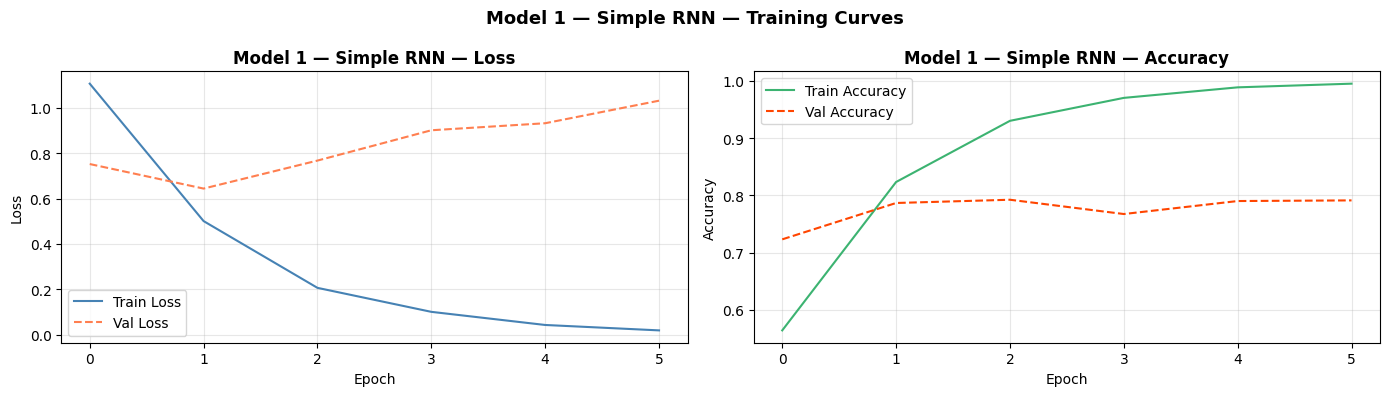


  Model 1 — Simple RNN
  Test Loss     : 0.6825
  Test Accuracy : 0.7810 (78.10%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.51      0.70      0.59       215
     EDUCATION       0.65      0.54      0.59       203
         MONEY       0.78      0.65      0.71       351
        SPORTS       0.87      0.90      0.89      1015
          TECH       0.80      0.76      0.78       421

      accuracy                           0.78      2205
     macro avg       0.72      0.71      0.71      2205
  weighted avg       0.79      0.78      0.78      2205



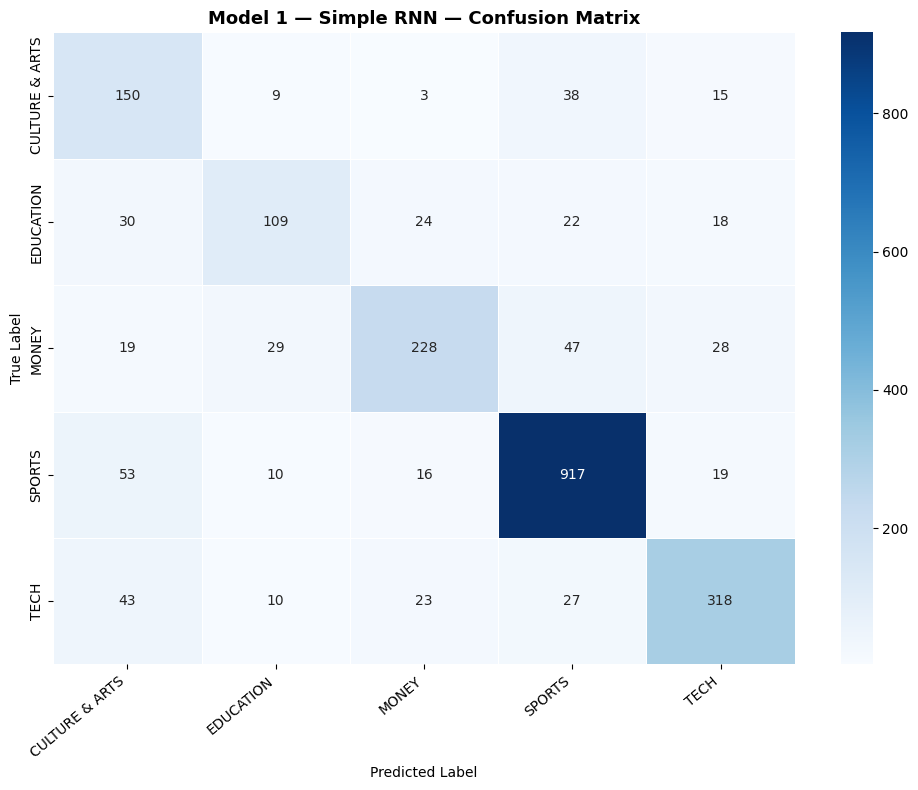

In [ ]:
plot_history(history1, 'Model 1 — Simple RNN')
acc1, pred1, true1 = evaluate_model(model1, X_test_seq, y_test_cat, 'Model 1 — Simple RNN')


##  — Model 2: LSTM with Trainable Embedding

In [ ]:
tf.random.set_seed(42)

model2 = Sequential(name='LSTM_Model', layers=[
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='embedding_2'),
    LSTM(64, return_sequences=False, name='lstm_layer'),
    Dropout(0.3, name='dropout_3'),
    Dense(64, activation='relu', name='dense_hidden_2'),
    Dropout(0.2, name='dropout_4'),
    Dense(num_classes, activation='softmax', name='output_2')
])

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_2 (Dense)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_2 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Training Model 2: LSTM...")
start2 = time.time()

history2 = model2.fit(
    X_train_seq, y_train_cat,
    epochs=20, batch_size=64,
    validation_split=0.10,
    callbacks=get_callbacks(),
    verbose=1
)

train_time2 = time.time() - start2
print(f"\n Model 2 Training Time: {train_time2:.1f} seconds")

Training Model 2: LSTM...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5142 - loss: 1.2037 - val_accuracy: 0.6497 - val_loss: 0.9267 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7183 - loss: 0.6967 - val_accuracy: 0.7687 - val_loss: 0.6037 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8903 - loss: 0.3088 - val_accuracy: 0.8005 - val_loss: 0.7297 - learning_rate: 0.0010
Epoch 4/20
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9474 - loss: 0.1669
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9568 - loss: 0.1436 - val_accuracy: 0.7948 - val_loss: 0.7759 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9786 - loss: 0.0770 - val_accuracy: 0.8084 - val_loss: 0.8500 - learning_rate: 5.0000e-04
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - ac

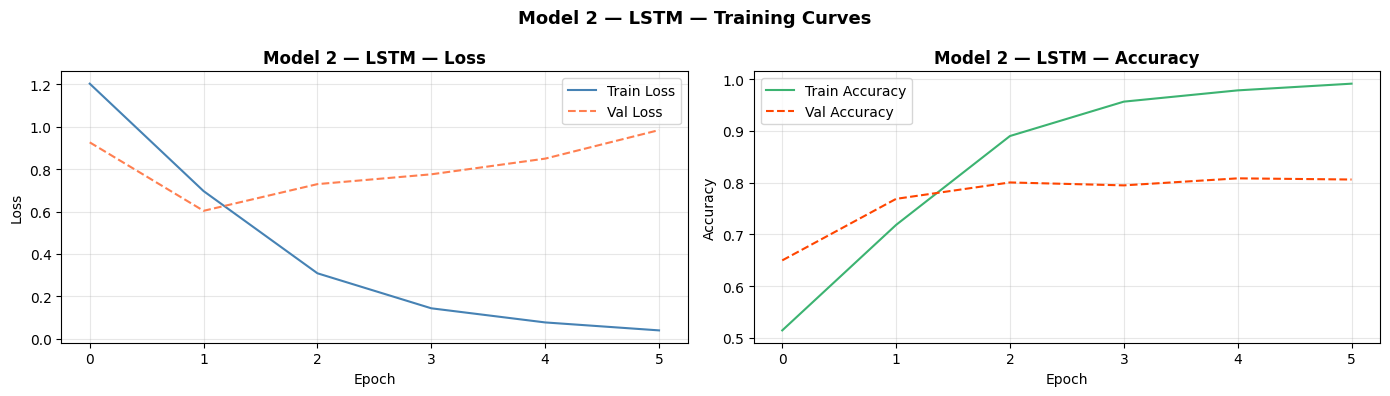


  Model 2 — LSTM
  Test Loss     : 0.6027
  Test Accuracy : 0.7660 (76.60%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.39      0.39      0.39       215
     EDUCATION       0.42      0.62      0.50       203
         MONEY       0.80      0.69      0.74       351
        SPORTS       0.94      0.90      0.92      1015
          TECH       0.78      0.77      0.77       421

      accuracy                           0.77      2205
     macro avg       0.66      0.67      0.66      2205
  weighted avg       0.79      0.77      0.77      2205



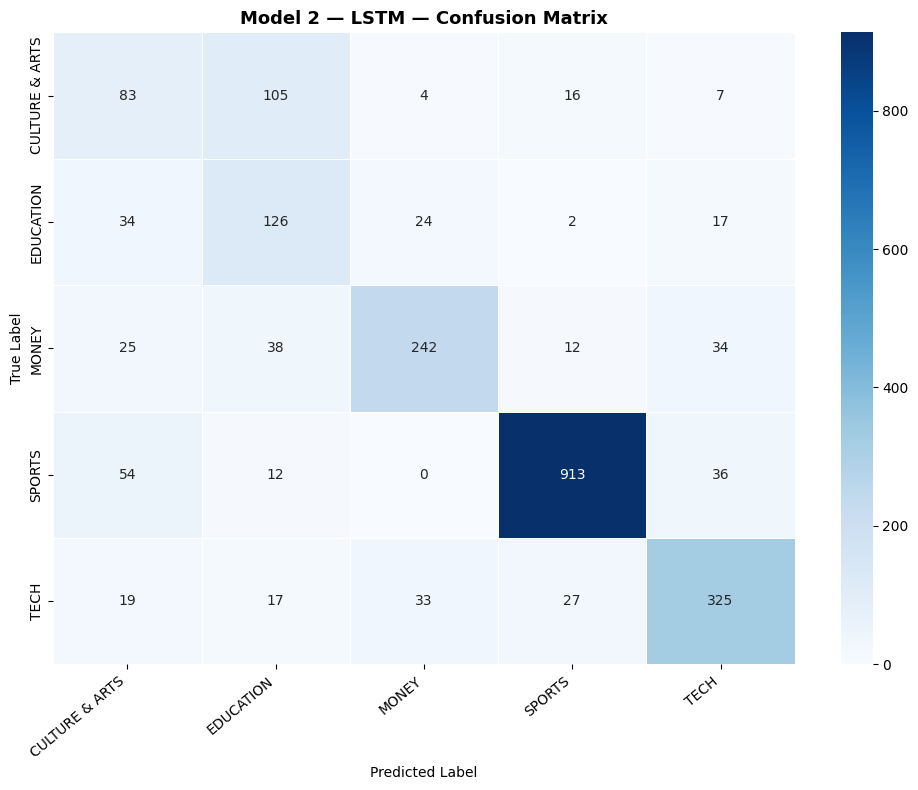

In [ ]:
plot_history(history2, 'Model 2 — LSTM')
acc2, pred2, true2 = evaluate_model(model2, X_test_seq, y_test_cat, 'Model 2 — LSTM')


##10 — Model 3: BiLSTM + GloVe Twitter 100 (Pre-trained Embeddings)

**Why GloVe Twitter 100?**  
GloVe Twitter embeddings are trained on 2 billion tweets, capturing informal and concise language patterns similar to news headlines. Using them as a frozen embedding layer is a form of **transfer learning** — we apply knowledge from a large corpus to our smaller dataset, improving generalisation without extra training data.

In [ ]:
import gensim.downloader as api

print("Loading GloVe Twitter 100 embeddings...")
print("(~171MB — cached after first download)")
glove_model = api.load('glove-twitter-100')
print(f"GloVe loaded. Vocab size: {len(glove_model)} | Dimensions: 100")

Loading GloVe Twitter 100 embeddings...
(~171MB — cached after first download)
[==================================================] 100.0% 387.1/387.1MB downloaded
✅ GloVe loaded. Vocab size: 1193514 | Dimensions: 100


##Build Embedding Matrix

In [ ]:

EMBED_DIM_GLOVE = 100
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_GLOVE))
found = 0
not_found = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100
print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Words found in GloVe   : {found}  ({coverage:.1f}%)")
print(f"Words not found        : {not_found} ({100-coverage:.1f}%) → assigned zero vectors")

Embedding matrix shape : (11997, 100)
Words found in GloVe   : 10783  (89.9%)
Words not found        : 1213 (10.1%) → assigned zero vectors


## Build BiLSTM Model

In [ ]:
tf.random.set_seed(42)

model3 = Sequential(name='BiLSTM_GloVe_Model', layers=[
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM_GLOVE,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,           # freeze pre-trained weights
        name='glove_embedding'
    ),
    Bidirectional(LSTM(64, return_sequences=False), name='bilstm_layer'),
    Dropout(0.3, name='dropout_5'),
    Dense(64, activation='relu', name='dense_hidden_3'),
    Dropout(0.2, name='dropout_6'),
    Dense(num_classes, activation='softmax', name='output_3')
])

model3.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)
model3.summary()

Model: "BiLSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,199,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_layer (Bidirectional)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_3 (Dense)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_3 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,700 (4.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,199,700 (4.58 MB)

In [ ]:
print("Training Model 3: BiLSTM + GloVe Twitter 100...")
start3 = time.time()

history3 = model3.fit(
    X_train_seq, y_train_cat,
    epochs=20, batch_size=64,
    validation_split=0.10,
    callbacks=get_callbacks(),
    verbose=1
)

train_time3 = time.time() - start3
print(f"\n✅ Model 3 Training Time: {train_time3:.1f} seconds")

Training Model 3: BiLSTM + GloVe Twitter 100...
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7389 - loss: 0.7222 - val_accuracy: 0.8413 - val_loss: 0.4610 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8501 - loss: 0.4378 - val_accuracy: 0.8492 - val_loss: 0.4293 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8694 - loss: 0.3898 - val_accuracy: 0.8696 - val_loss: 0.4088 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8783 - loss: 0.3566 - val_accuracy: 0.8776 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8918 - loss: 0.3211 - val_accuracy: 0.8673 - val_loss: 0.4048 - learning_rate: 0.0010
Epoch 6/20
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9004 - loss: 0.2946
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
125/125 ━━━━━━━━━━━━━━━━━━━━

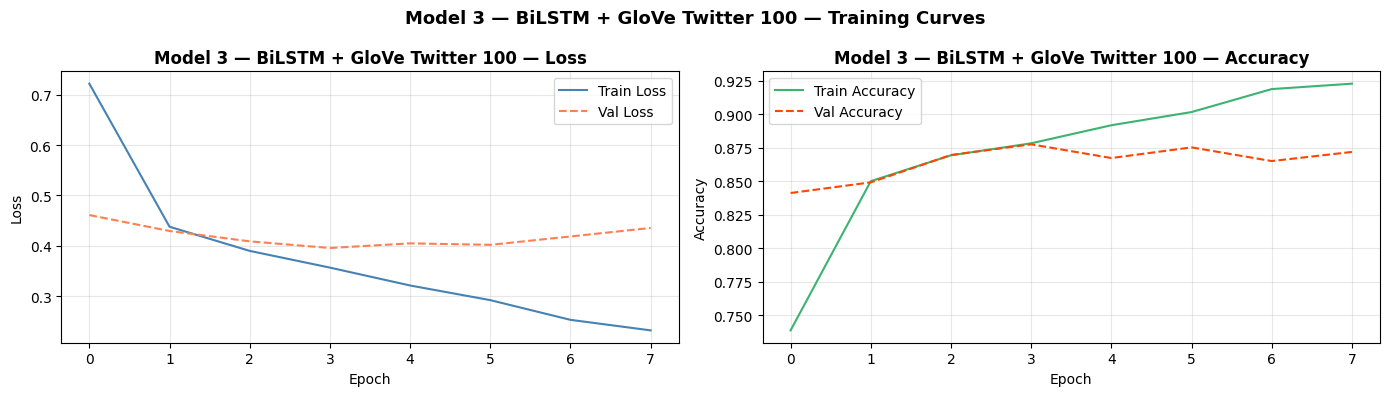


  Model 3 — BiLSTM + GloVe
  Test Loss     : 0.4260
  Test Accuracy : 0.8481 (84.81%)

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.72      0.80      0.76       215
     EDUCATION       0.67      0.73      0.70       203
         MONEY       0.79      0.76      0.78       351
        SPORTS       0.95      0.92      0.93      1015
          TECH       0.82      0.84      0.83       421

      accuracy                           0.85      2205
     macro avg       0.79      0.81      0.80      2205
  weighted avg       0.85      0.85      0.85      2205



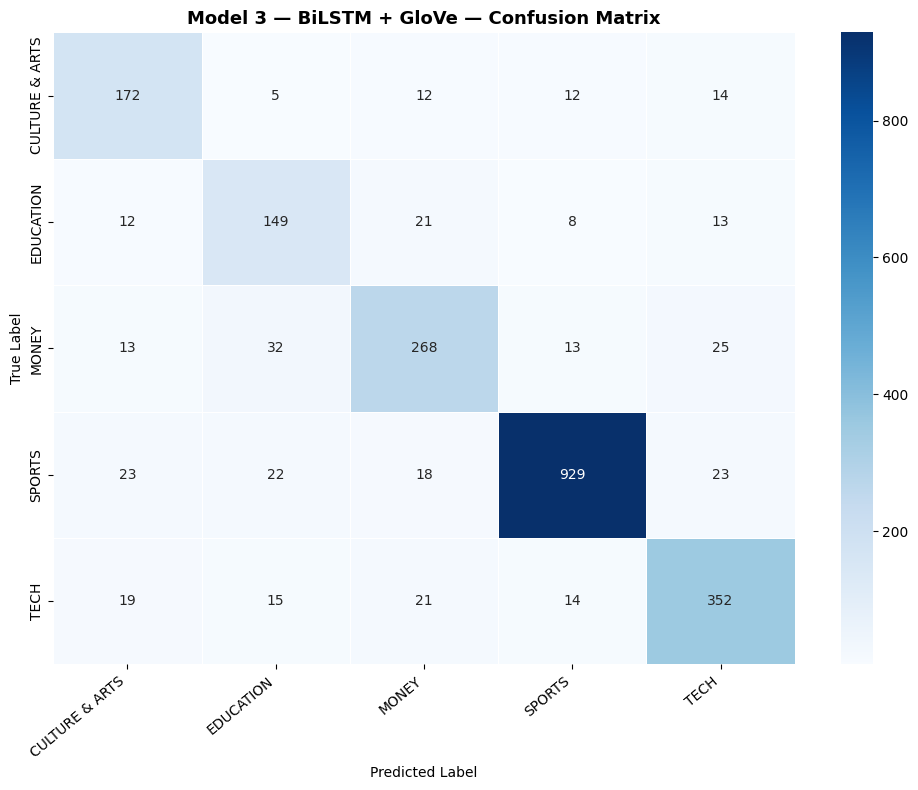

In [ ]:
plot_history(history3, 'Model 3 — BiLSTM + GloVe Twitter 100')
acc3, pred3, true3 = evaluate_model(model3, X_test_seq, y_test_cat, 'Model 3 — BiLSTM + GloVe')

---
## 📊 Section 11 — Comparative Analysis: All 3 Models

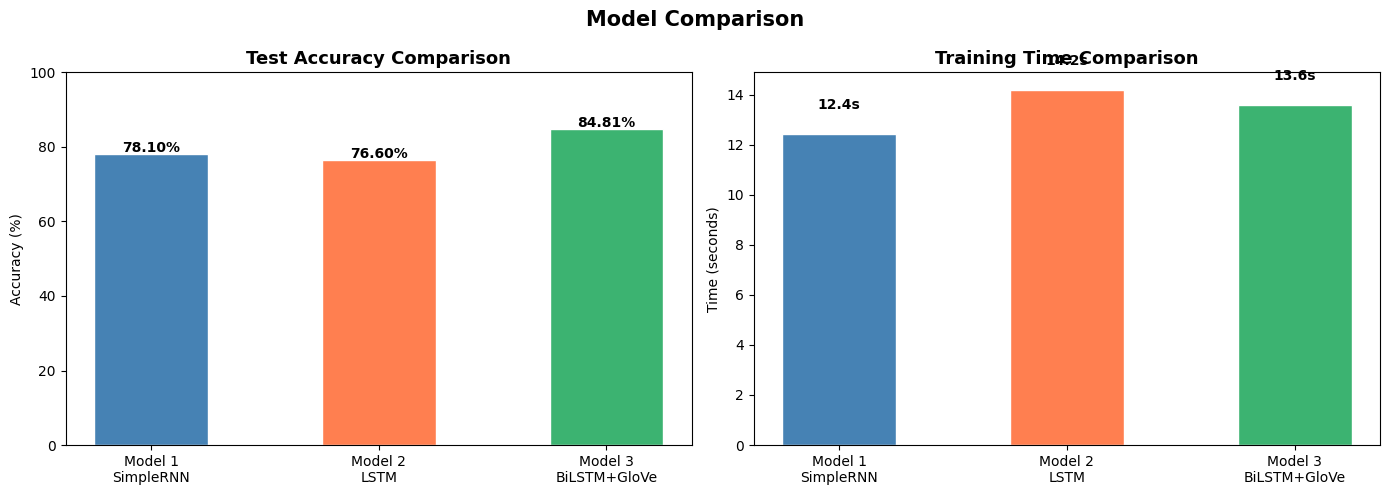

In [ ]:
model_names = ['Model 1\nSimpleRNN', 'Model 2\nLSTM', 'Model 3\nBiLSTM+GloVe']
accuracies  = [acc1, acc2, acc3]
train_times = [train_time1, train_time2, train_time3]
bar_colors  = ['steelblue', 'coral', 'mediumseagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(model_names, [a * 100 for a in accuracies],
                   color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{acc*100:.2f}%', ha='center', fontweight='bold')

axes[1].bar(model_names, train_times, color=bar_colors, edgecolor='white', width=0.5)
axes[1].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
for i, t in enumerate(train_times):
    axes[1].text(i, t + 1, f'{t:.1f}s', ha='center', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

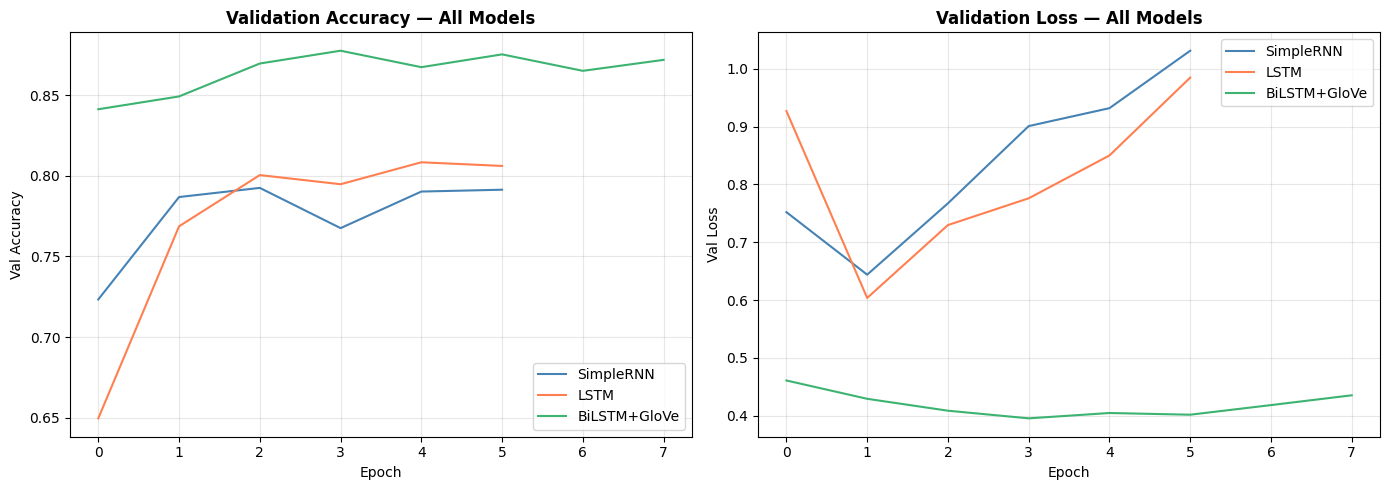

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['val_accuracy'], label='SimpleRNN',     color='steelblue')
axes[0].plot(history2.history['val_accuracy'], label='LSTM',          color='coral')
axes[0].plot(history3.history['val_accuracy'], label='BiLSTM+GloVe', color='mediumseagreen')
axes[0].set_title('Validation Accuracy — All Models', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history1.history['val_loss'], label='SimpleRNN',     color='steelblue')
axes[1].plot(history2.history['val_loss'], label='LSTM',          color='coral')
axes[1].plot(history3.history['val_loss'], label='BiLSTM+GloVe', color='mediumseagreen')
axes[1].set_title('Validation Loss — All Models', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

def get_metrics(y_true, y_pred):
    return {
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score':  f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

m1 = get_metrics(true1, pred1)
m2 = get_metrics(true2, pred2)
m3 = get_metrics(true3, pred3)

summary_df = pd.DataFrame({
    'Model':      ['SimpleRNN', 'LSTM', 'BiLSTM + GloVe Twitter 100'],
    'Accuracy':   [f'{acc1*100:.2f}%', f'{acc2*100:.2f}%', f'{acc3*100:.2f}%'],
    'Precision':  [f'{m1["Precision"]:.4f}', f'{m2["Precision"]:.4f}', f'{m3["Precision"]:.4f}'],
    'Recall':     [f'{m1["Recall"]:.4f}',    f'{m2["Recall"]:.4f}',    f'{m3["Recall"]:.4f}'],
    'F1-Score':   [f'{m1["F1-Score"]:.4f}',  f'{m2["F1-Score"]:.4f}',  f'{m3["F1-Score"]:.4f}'],
    'Train Time': [f'{train_time1:.1f}s',    f'{train_time2:.1f}s',    f'{train_time3:.1f}s']
})

print("\n" + "="*72)
print("                   MODEL COMPARISON SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))
print("="*72)


                   MODEL COMPARISON SUMMARY
                     Model Accuracy Precision Recall F1-Score Train Time
                 SimpleRNN   78.10%    0.7873 0.7810   0.7810      12.4s
                      LSTM   76.60%    0.7851 0.7660   0.7729      14.2s
BiLSTM + GloVe Twitter 100   84.81%    0.8527 0.8481   0.8498      13.6s



## 12 — Error Analysis

In [ ]:
# ── Misclassified Examples — Model 3 ────────────────────────────
X_test_list = X_test_raw.tolist()

errors = [
    {
        'headline':  X_test_list[i],
        'true':      le.classes_[true3[i]],
        'predicted': le.classes_[pred3[i]]
    }
    for i in range(len(true3)) if true3[i] != pred3[i]
]

print(f"Total misclassifications (Model 3): {len(errors)} / {len(true3)}")
print(f"Error rate: {len(errors)/len(true3)*100:.2f}%")
print("\n" + "="*65)
print("SAMPLE MISCLASSIFIED HEADLINES")
print("="*65)
for i, e in enumerate(errors[:5]):
    print(f"\nExample {i+1}:")
    print(f"  Headline  : {e['headline']}")
    print(f"  True      : {e['true']}")
    print(f"  Predicted : {e['predicted']}")

Total misclassifications (Model 3): 335 / 2205
Error rate: 15.19%

SAMPLE MISCLASSIFIED HEADLINES

Example 1:
  Headline  : judicial negligence compound political negligence south carolina
  True      : EDUCATION
  Predicted : CULTURE & ARTS

Example 2:
  Headline  : go back grad school
  True      : MONEY
  Predicted : EDUCATION

Example 3:
  Headline  : social medium con artist
  True      : TECH
  Predicted : CULTURE & ARTS

Example 4:
  Headline  : teach america houston tshirt sale
  True      : EDUCATION
  Predicted : MONEY

Example 5:
  Headline  : father day love faith work
  True      : CULTURE & ARTS
  Predicted : EDUCATION


In [ ]:
# ── Most Confused Category Pairs ─────────────────────────────────
confusion_pairs = defaultdict(int)
for e in errors:
    confusion_pairs[f"{e['true']} → {e['predicted']}"] += 1

top_confusions = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Most Confused Category Pairs (Model 3):")
for pair, count in top_confusions:
    print(f"  {pair:40s} → {count} times")

Top 10 Most Confused Category Pairs (Model 3):
  MONEY → EDUCATION                        → 32 times
  MONEY → TECH                             → 25 times
  SPORTS → CULTURE & ARTS                  → 23 times
  SPORTS → TECH                            → 23 times
  SPORTS → EDUCATION                       → 22 times
  EDUCATION → MONEY                        → 21 times
  TECH → MONEY                             → 21 times
  TECH → CULTURE & ARTS                    → 19 times
  SPORTS → MONEY                           → 18 times
  TECH → EDUCATION                         → 15 times


### Error Analysis Discussion

**Observations from misclassifications:**

1. **Short headlines with ambiguous words** — After removing stopwords, only 2–4 meaningful words remain, making context highly ambiguous.

2. **Category overlap** — TECH and EDUCATION share words like *learning*, *students*, *program*. SPORTS and CULTURE share person names.

3. **Out-of-vocabulary words** — Proper nouns (athlete names, movie titles, politicians) are rarely in GloVe and are mapped to zero vectors.

**Suggested Improvements:**
- Use Named Entity Recognition (NER) as an additional feature
- Fine-tune the embedding layer (`trainable=True`) after initial frozen training
- Use a transformer-based model (BERT, DistilBERT) for richer contextual understanding
- Apply class weights to address any class imbalance


##  13 — Real-Time Prediction Interface (Gradio GUI)

In [ ]:
import gradio as gr

def predict_category(headline_text, selected_model):
    if not headline_text.strip():
        return "Please enter a headline."

    cleaned = clean_text(headline_text)
    if not cleaned.strip():
        return "Headline too short after cleaning. Try a longer headline."

    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    model_map = {
        'Model 1 — Simple RNN':         model1,
        'Model 2 — LSTM':               model2,
        'Model 3 — BiLSTM + GloVe 100': model3
    }
    model = model_map[selected_model]

    probs      = model.predict(padded, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_label = le.classes_[pred_idx]
    confidence = probs[pred_idx] * 100

    all_probs = '\n'.join([
        f"  {le.classes_[i]:<25s}: {probs[i]*100:5.1f}%"
        for i in np.argsort(probs)[::-1]
    ])

    return (
        f"Cleaned Headline : {cleaned}\n\n"
        f"Predicted Category : {pred_label}\n"
        f"Confidence         : {confidence:.1f}%\n\n"
        f"All Probabilities:\n{all_probs}"
    )


iface = gr.Interface(
    fn=predict_category,
    inputs=[
        gr.Textbox(
            label="Enter a News Headline",
            placeholder="e.g. Scientists discover new species in Amazon rainforest",
            lines=2
        ),
        gr.Dropdown(
            choices=[
                'Model 1 — Simple RNN',
                'Model 2 — LSTM',
                'Model 3 — BiLSTM + GloVe 100'
            ],
            value='Model 3 — BiLSTM + GloVe 100',
            label="Select Model"
        )
    ],
    outputs=gr.Textbox(label="Prediction Result", lines=12),
    title="📰 News Category Predictor",
    description="Enter a news headline and select a model to predict its category.",
    examples=[
        ["NASA launches new moon mission with international crew",      "Model 3 — BiLSTM + GloVe 100"],
        ["LeBron James scores 40 points in overtime thriller",         "Model 3 — BiLSTM + GloVe 100"],
        ["New iPhone model expected to feature foldable display",      "Model 2 — LSTM"],
        ["Students protest rising tuition fees at state universities", "Model 1 — Simple RNN"],
        ["Award-winning director announces sequel to hit film",        "Model 3 — BiLSTM + GloVe 100"]
    ],
    theme=gr.themes.Soft()
)

iface.launch(share=True)   # share=True generates a public link in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c14913622900255ddd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



##  14 — Save Models

In [ ]:
# Save to Colab's local storage (download manually or mount Google Drive)
model1.save('model1_simplernn.h5')
model2.save('model2_lstm.h5')
model3.save('model3_bilstm_glove.h5')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ All models and tokenizer saved.")

# Optional: download files directly to your PC
# from google.colab import files
# files.download('model1_simplernn.h5')
# files.download('model2_lstm.h5')
# files.download('model3_bilstm_glove.h5')
# files.download('tokenizer.pkl')
# files.download('label_encoder.pkl')

✅ All models and tokenizer saved.




## 15 — Final Summary & Observations

In [ ]:
print("="*70)
print("              FINAL PROJECT SUMMARY")
print("="*70)
print(f"""
Dataset        : News Category (headline → category)
Total Samples  : {len(df)}
Categories     : {num_classes} ({', '.join(le.classes_)})
Train/Test     : 80% / 20% (stratified split)
Vocabulary     : {VOCAB_SIZE} words (capped)
Max Seq Length : {MAX_LEN} (95th percentile of training lengths)

─── Model Performance ───────────────────────────────────────────
  Model 1 — SimpleRNN        : {acc1*100:.2f}%  |  {train_time1:.1f}s
  Model 2 — LSTM             : {acc2*100:.2f}%  |  {train_time2:.1f}s
  Model 3 — BiLSTM + GloVe   : {acc3*100:.2f}%  |  {train_time3:.1f}s

─── Key Observations ────────────────────────────────────────────
  • Simple RNN struggles with long-range dependencies due to
    vanishing gradients.
  • LSTM improves over RNN using gating mechanisms that
    retain relevant context across sequences.
  • BiLSTM + GloVe achieves best performance by processing
    sequences both forward and backward, combined with
    transfer learning from 2B Twitter-trained word vectors.
  • EarlyStopping + ReduceLROnPlateau prevented overfitting.
  • GloVe embeddings were frozen (trainable=False) to
    preserve pre-learned semantic representations.

─── Hardware ────────────────────────────────────────────────────
  Platform : Google Colab
  GPU      : {str(tf.config.list_physical_devices('GPU'))}
""")
print("="*70)

              FINAL PROJECT SUMMARY

Dataset        : News Category (headline → category)
Total Samples  : 11025
Categories     : 5 (CULTURE & ARTS, EDUCATION, MONEY, SPORTS, TECH)
Train/Test     : 80% / 20% (stratified split)
Vocabulary     : 11997 words (capped)
Max Seq Length : 11 (95th percentile of training lengths)

─── Model Performance ───────────────────────────────────────────
  Model 1 — SimpleRNN        : 78.10%  |  12.4s
  Model 2 — LSTM             : 76.60%  |  14.2s
  Model 3 — BiLSTM + GloVe   : 84.81%  |  13.6s

─── Key Observations ────────────────────────────────────────────
  • Simple RNN struggles with long-range dependencies due to
    vanishing gradients.
  • LSTM improves over RNN using gating mechanisms that
    retain relevant context across sequences.
  • BiLSTM + GloVe achieves best performance by processing
    sequences both forward and backward, combined with
    transfer learning from 2B Twitter-trained word vectors.
  • EarlyStopping + ReduceLROnPlateau

In [ ]:
model1.save('model1_simplernn.keras')
model2.save('model2_lstm.keras')
model3.save('model3_bilstm_glove.keras')